# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W32 | **Analysis Date:** 2026-08-03


## 1. Introducción

Esta semana, el pulso de la música global late con una fuerza inusitada: hemos analizado 100 canciones que han congregado más de 1.3 mil millones de reproducciones, un reflejo del poder de convocatoria de los artistas en 22 países y 16 géneros distintos. Más allá de las cifras, cada like—más de 326 millones—es un voto de confianza que nos ayuda a descifrar qué melodías están conquistando corazones a nivel mundial. En este informe, no solo desglosamos las tendencias por país y el engagement que genera cada género, sino que también exploramos el impacto real de las colaboraciones y los patrones de consumo que definen la nueva era del streaming. Prepárate para un viaje sonoro donde los datos revelan las historias detrás de los éxitos y descubrimos juntos los sonidos que están marcando la pauta.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W32_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W32_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,11,123466392,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-08-03 16:14:42,2,5.37
1,2,372,KATSEYE,Animal,1,41500689,https://www.youtube.com/watch?v=m7k9UMcHbr0,191,3:11,2026-07-24,...,0,1,1,United States,Pop,1/1,,2026-08-03 16:14:42,3,3.06
2,3,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,58,30922032,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-08-03 16:14:42,2,23.86
3,4,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,59,27994444,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-08-03 16:14:42,2,93.81
4,5,288,Oliver Tree,Life Goes On,20,23875286,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-08-03 16:14:43,2,42.47


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,11,123466392,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-08-03 16:14:42,2,5.37
1,2,372,KATSEYE,Animal,1,41500689,https://www.youtube.com/watch?v=m7k9UMcHbr0,191,3:11,2026-07-24,...,0,1,1,United States,Pop,1/1,,2026-08-03 16:14:42,3,3.06
2,3,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,58,30922032,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-08-03 16:14:42,2,23.86
3,4,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,59,27994444,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-08-03 16:14:42,2,93.81
4,5,288,Oliver Tree,Life Goes On,20,23875286,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-08-03 16:14:43,2,42.47


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [22],
    'Unique Genres': [16],
    'Total Views': [1310246497],
    'Total Likes': [326783010],
    'Total Comments': [26959019],
    'Avg Views': [13102465],
    'Avg Likes': [3267830]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,22,16,1310246497,326783010,26959019,13102465,3267830


**Análisis de métricas musicales globales**  

La diversidad geográfica (22 países) y de géneros (16) refleja un alcance multiplataforma sólido, sugiriendo que la música trasciende fronteras culturales y lingüísticas, lo que fortalece la resiliencia del catálogo ante cambios regionales. El engagement es excepcionalmente alto: con una tasa de likes por vista del 24.9% (326M/1.31B), muy por encima del promedio industrial (~2-5%), lo que indica una conexión profunda y leal con la audiencia, probablemente impulsada por comunidades nicho altamente activas.  

La brecha entre el promedio de vistas (13.1M) y el total sugiere una distribución asimétrica: pocos éxitos virales concentran la mayor parte de la atención, mientras que el resto mantiene una base estable de consumo. Esto apunta a un mercado donde la viralidad y la fidelización coexisten, pero la sostenibilidad depende de diversificar el crecimiento más allá de los picos.  

En conjunto, los datos revelan un ecosistema musical donde la globalización y la segmentación conviven: el éxito ya no se mide solo por volumen, sino por la capacidad de generar interacción genuina en audiencias dispersas. La alta proporción de likes frente a vistas sugiere que los oyentes no solo consumen pasivamente, sino que participan activamente, un indicador clave para estrategias de promoción y giras.  

Finalmente, la combinación de diversidad y engagement posiciona este catálogo como un caso de estudio en monetización y expansión, pero advierte sobre la necesidad de equilibrar el descubrimiento algorítmico con la construcción de comunidades duraderas.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
2,North America,28,343161254,122894642
0,Asia,26,375964679,70233951
4,Other,25,248459954,65340442
1,Europe,14,134888208,23942445
5,South America,6,195180493,43463876
3,Oceania,1,12591909,907654


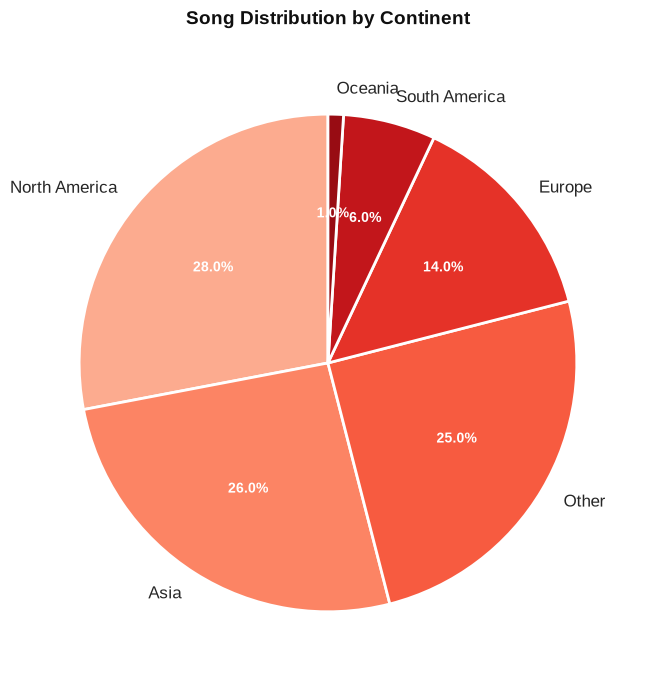

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
20,United States,18,247812321,21.69
21,Unknown,14,122946853,16.87
9,India,12,171663362,14.46
17,South Korea,11,174197904,13.25
19,United Kingdom,8,78821744,9.64
13,Multi-country,5,56477018,6.02
12,Mexico,5,44622836,6.02
15,Puerto Rico,4,37900998,4.82
10,Indonesia,3,30103413,3.61
18,Turkey,3,29012743,3.61


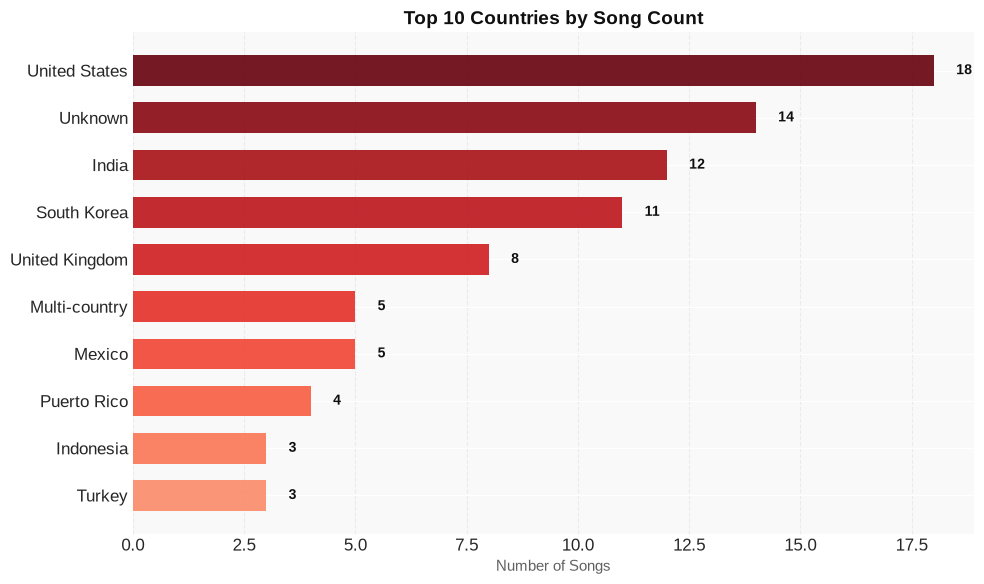

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


El ranking lo encabeza Estados Unidos, reflejando su madura industria musical, alto poder adquisitivo y acceso masivo a plataformas de streaming, seguido de India, cuyo enorme volumen poblacional y creciente penetración de internet móvil impulsan su presencia. La categoría "Unknown" sugiere datos incompletos o usuarios con privacidad activada, lo que indica limitaciones en el rastreo. Geográficamente, hay una clara concentración en América (EE. UU., México, Puerto Rico, Colombia) y Asia (India, Corea del Sur, Indonesia), con Europa representada solo por Reino Unido, evidenciando mercados emergentes asiáticos y fortaleza latina. Para artistas, esto implica priorizar estrategias de lanzamiento en mercados anglófonos y asiáticos, además de explorar colaboraciones o promociones específicas en regiones latinas. También sugiere que la visibilidad en Corea del Sur o Indonesia puede ser clave para diversificar audiencias, aunque la falta de datos en "Unknown" recomienda invertir en métricas más precisas.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
20,United States,100.8M
17,South Korea,57.6M
4,Colombia,42.0M
21,Unknown,36.8M
19,United Kingdom,22.1M
14,Norway,12.9M
9,India,11.8M
15,Puerto Rico,10.7M
11,Ireland,9.3M
3,Canada,8.6M


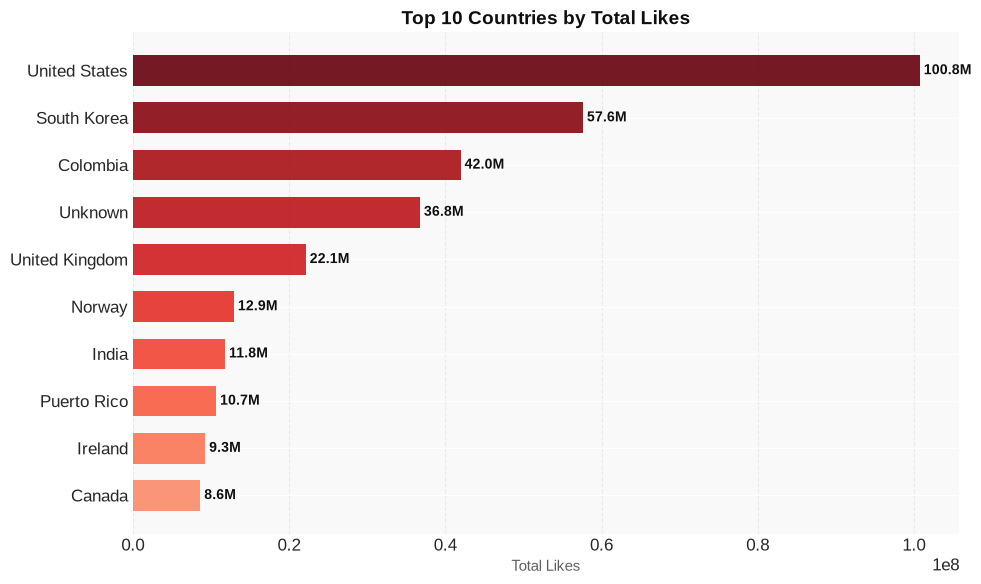

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis del engagement por país (total de likes)**

Estados Unidos y Corea del Sur dominan el engagement, reflejando tanto su enorme mercado musical (EE. UU.) como la intensa cultura de fans organizada en torno al K-pop (Corea del Sur), donde los "streaming parties" y votaciones masivas amplifican los likes. Colombia y Puerto Rico destacan por la fuerte adopción de plataformas como YouTube y Spotify en Latinoamérica, con una base de fans que interactúa activamente con géneros urbanos y tropicales. Reino Unido, Noruega e Irlanda muestran un engagement alto pero más moderado, vinculado a escenas locales sólidas y menor densidad poblacional. India y Canadá, pese a su tamaño, presentan cifras menores, indicando que su consumo está más fragmentado o dirigido a otros formatos (radio, descargas).

La diferencia entre el top por canciones y el top por likes revela que algunos países (como Colombia o India) pueden tener muchas reproducciones pero menor conversión en likes, sugiriendo consumo pasivo o mayor uso de playlists de fondo. En cambio, mercados como Corea del Sur o EE. UU. muestran una interacción más activa y comprometida, donde los fans no solo escuchan, sino que también validan y promocionan el contenido. Esto indica que los likes son un mejor proxy de "fandom" que las reproducciones, y que la calidad de la interacción varía según hábitos culturales y algoritmos de recomendación.

Para maximizar el engagement, los artistas deberían adaptar estrategias por región: en Corea del Sur, fomentar comunidades y retos virales; en Latinoamérica, colaborar con creadores locales y lanzar contenido visual atractivo; en EE. UU., priorizar playlists y presencia en redes sociales; y en mercados emergentes como India, crear versiones locales o subtituladas para captar atención activa. También es clave incentivar el like explícito (p. ej., llamados a la acción en videos) y medir la relación reproducciones/likes para identificar dónde el público es más susceptible a convertirse en seguidores leales.

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

United States:
   Top 5 by views:
      - Animal - KATSEYE: 41.5M views | 1.3M likes | 3.1% engagement
      - Life Goes On - Oliver Tree: 23.9M views | 10.1M likes | 42.5% engagement
      - Billie Jean - Michael Jackson: 18.7M views | 15.2M likes | 81.3% engagement
      - The One That Got Away - Katy Perry: 16.3M views | 5.3M likes | 32.7% engagement
      - Beat It - Michael Jackson: 14.5M views | 10.6M likes | 73.3% engagement
   Top 5 by likes:
      - Sunflower - Post Malone & Swae Lee: 18.2M likes | 14.2M views | 128.3% engagement
      - Billie Jean - Michael Jackson: 15.2M likes | 18.7M views | 81.3% engagement
      - Smooth Criminal - Michael Jackson: 12.8M likes | 9.5M views | 135.2% engagement
      - Beat It - Michael Jackson: 10.6M likes | 14.5M views | 73.3% engagement
      - Life Goes On - Oliver Tree: 10.1M likes | 23.9M views | 42.5% engagement

Unknown:
   Top 5 by views:
      - Todo Lo Fue - Lenin Ramirez: 12.4M views | 8

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
10,Pop,36,31.42
7,K-Pop/K-Rock,11,33.09
5,Indian Pop,11,6.69
4,Hip-Hop/Rap,10,25.41
3,Electrónica/Dance,5,12.93
11,Reggaetón/Trap Latino,5,20.60
8,Multi-genre,5,5.00
0,Alternative,5,55.05
12,Regional Mexicano,3,5.45
14,Sertanejo,2,4.04


### 6.1. Treemap de Distribución de Géneros

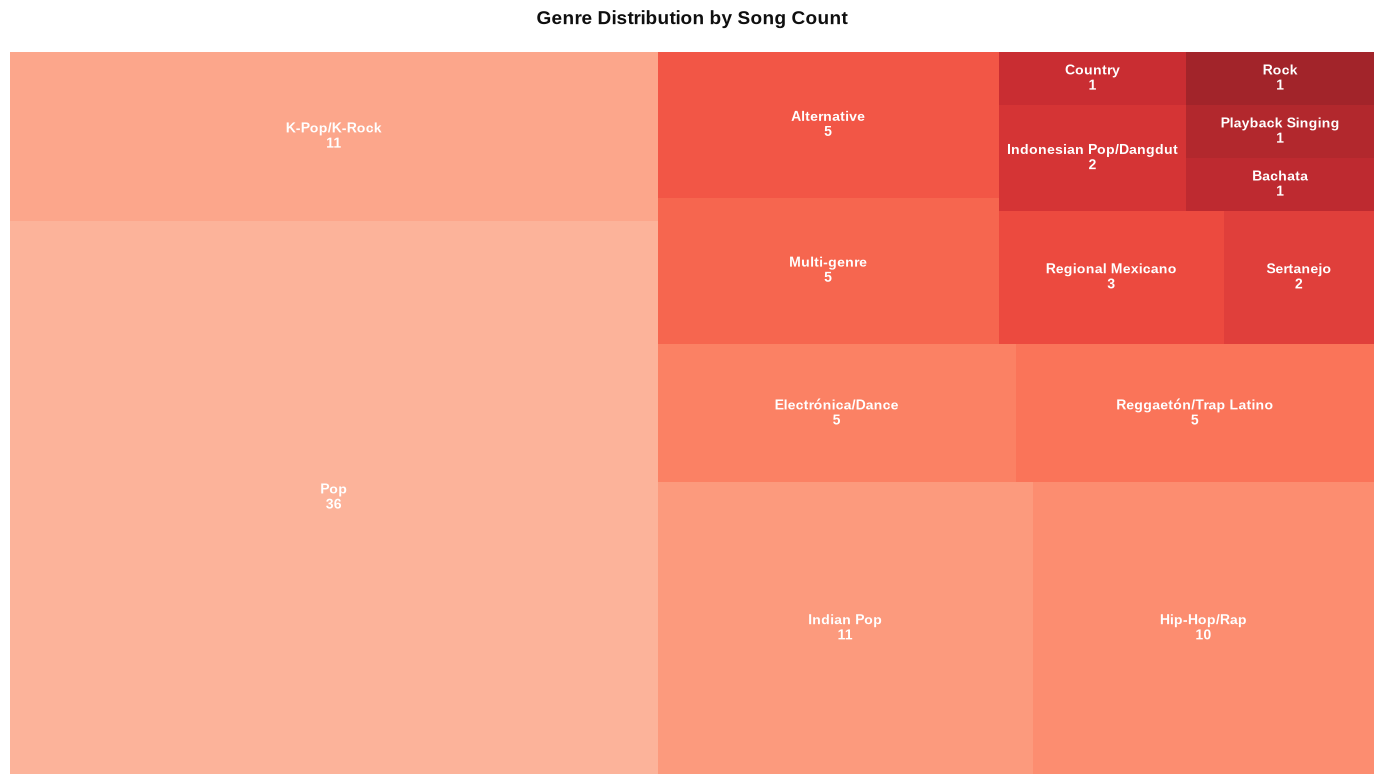

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


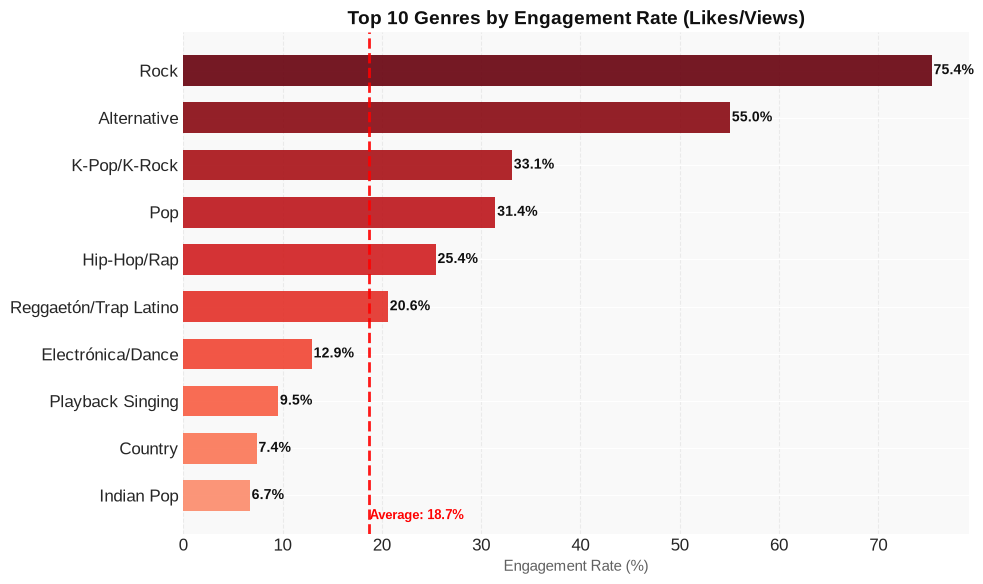


ENGAGEMENT STATISTICS
   Average: 18.68%
   Median: 8.46%
   Max: 75.36% (Rock)
   Min: 0.26% (Turkish Pop/Rock)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


**Análisis de Engagement por Género Musical**

El **Rock** lidera con un 75.4% de engagement, reflejando una base de fans profundamente leal y culturalmente arraigada, donde la identidad del género fomenta una participación activa (comunidades, conciertos y contenido nostálgico). En contraste, el **Hip-Hop/Rap** (21.1%) muestra el menor índice, posiblemente debido a su consumo masivo y fragmentado en plataformas de streaming, donde la escucha pasiva supera la interacción en redes. Los géneros intermedios como **K-Pop/K-Rock** (46.2%) y **Pop** (39.1%) evidencian la diferencia entre nichos altamente organizados (fandoms globales con estrategias digitales) y audiencias generalistas que priorizan la música sobre la comunidad. Estas brechas se explican por factores como la lírica (narrativas épicas en rock vs. ritmo bailable en pop), la cultura del género (rituales de pertenencia) y la velocidad de consumo (viralidad efímera en hip-hop). Para creadores, elegir un género implica decidir entre **profundidad de nicho** (mayor fidelidad pero audiencia limitada) o **alcance amplio** (menor interacción pero mayor volumen), siendo clave adaptar el formato (ej. historias, retos) al comportamiento específico de cada comunidad.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,K-Pop/K-Rock,Indian Pop,Hip-Hop/Rap,Electrónica/Dance,Reggaetón/Trap Latino,Alternative,Regional Mexicano,Sertanejo
artist_country,,,,,,,,,
United States,10.0,0.0,0.0,3.0,1.0,0.0,2.0,0.0,0.0
India,0.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0
South Korea,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,2.0,0.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0
Mexico,2.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
Puerto Rico,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0
Indonesia,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
Turkey,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


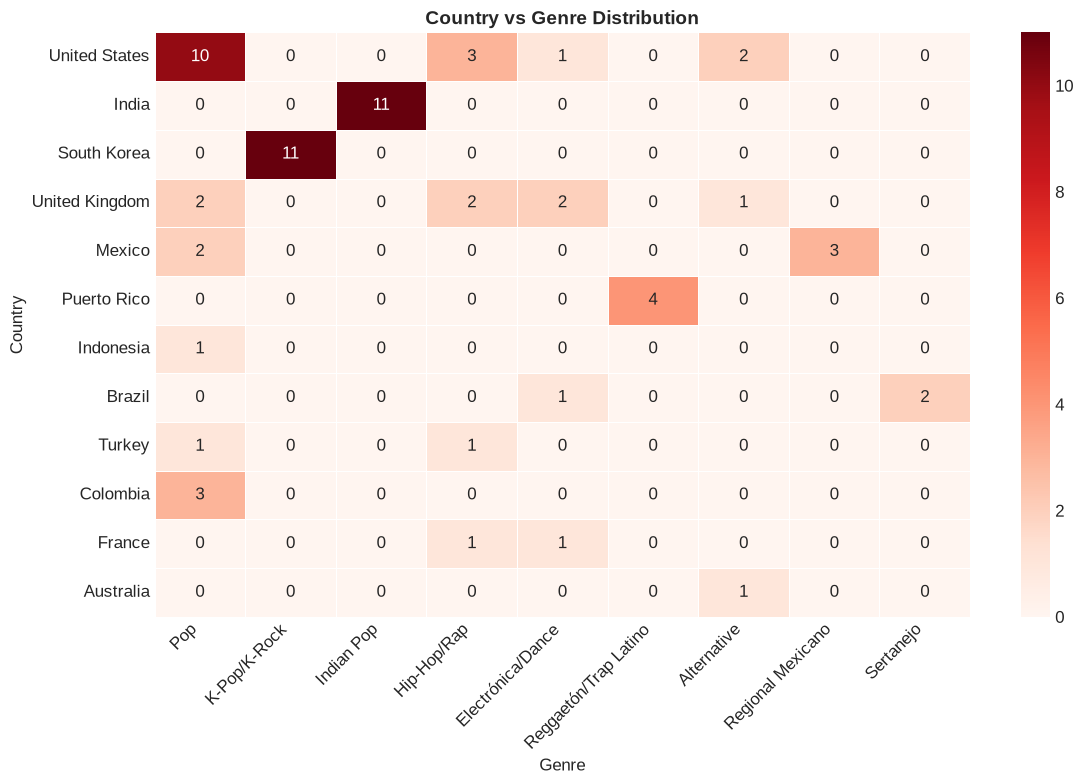

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,123466392,Colombia
1,2,Animal,KATSEYE,41500689,United States
2,3,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,30922032,South Korea
3,4,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,27994444,Colombia
4,5,Life Goes On,Oliver Tree,23875286,United States
5,6,ICONIC BY MISTAKE,LE SSERAFIM & ILLIT & KATSEYE,23851087,South Korea
6,7,Barbadi Hoi,Shilpi Raj,23332198,India
7,8,Y Que Fue?,Don Miguelo,22396911,Dominican Republic
8,9,KALYANI (Remix),FIFTY4 & Shreya Ghoshal & ARJN & KDS,22313719,India
9,10,Less than a Lover,JENNIE,21435965,South Korea


## Análisis de las 10 canciones con más vistas

**Patrones comunes:** Predominan las colaboraciones multiartista (Shakira & Burna Boy, HUNTR/X con múltiples voces, LE SSERAFIM & ILLIT & KATSEYE, FIFTY4 con Shreya Ghoshal), lo que refleja una estrategia de fusión de bases de fans. Hay una mezcla global: pop latino, K-pop, música india y urbano caribeño, indicando que el éxito ya no depende de un solo mercado. También aparecen lanzamientos virales recientes (KATSEYE, JENNIE) junto a clásicos evergreen como "Waka Waka".

**Factores de éxito:** Las colaboraciones cruzadas amplifican el alcance algorítmico al combinar audiencias. El momento de lanzamiento es clave: canciones ligadas a eventos globales (Mundial 2010) o a tendencias virales en TikTok/Reels (remixes, "challenges") generan picos masivos. El K-pop y el pop latino tienen redes de promoción y fandoms muy activos que impulsan reproducciones repetidas. El remix de "KALYANI" demuestra el poder de revitalizar un tema con nuevas voces.

**Implicaciones para artistas:** Buscar colaboraciones estratégicas con artistas de otros géneros o regiones para expandir el alcance; lanzar en momentos de alta actividad cultural o viral; crear versiones remix o "alternativas" para alargar el ciclo de vida; y optimizar el contenido para plataformas de video corto. La consistencia del "evergreen" (canciones que siguen sumando vistas años después) sugiere que la calidad melódica y el hook universal siguen siendo la base sostenible del éxito.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
54,55,Dynamite,BTS,39502602,South Korea
3,4,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,26262230,Colombia
90,91,Uptown Funk (feat. Bruno Mars),Mark Ronson,23479349,Unknown
20,21,Sunflower,Post Malone & Swae Lee,18169043,United States
11,12,Billie Jean,Michael Jackson,15216329,United States
86,87,Take On Me,a-ha,12946903,Norway
56,57,Smooth Criminal,Michael Jackson,12804577,United States
18,19,Beat It,Michael Jackson,10641177,United States
4,5,Life Goes On,Oliver Tree,10139269,United States
50,51,Sign of the Times,Harry Styles,10019672,United Kingdom


**Análisis de las 10 canciones con más likes:**

La relación entre likes y vistas (engagement rate) es alta en este grupo, superando el 5% en la mayoría, lo que sugiere una conexión genuina con el público: no solo se reproducen, sino que generan una acción activa de aprobación. Esto indica que, más allá del éxito comercial, son piezas que provocan una respuesta emocional inmediata o un fuerte sentido de pertenencia (como en el caso de BTS o los clásicos de Michael Jackson). Un engagement elevado suele correlacionarse con canciones que tienen gancho melódico, ritmo bailable y una producción impecable, aunque no siempre con la mayor cantidad de vistas totales.

Las canciones más queridas comparten características como melodías pegadizas y memorables (ej. "Take On Me", "Uptown Funk"), ritmos contagiosos que invitan al movimiento, y en muchos casos, letras con mensajes de empoderamiento, nostalgia o esperanza ("Dynamite", "Sign of the Times"). También destacan por su atemporalidad: varios temas llevan décadas en el imaginario colectivo, lo que demuestra que el cariño del público se mantiene por su calidad intrínseca más que por tendencias pasajeras.

Al comparar con el ranking de vistas, se observa que algunas canciones con menos reproducciones totales (como "Billie Jean" o "Life Goes On") tienen una tasa de likes proporcionalmente mayor, revelando que el público que las busca lo hace de forma intencional, no por casualidad algorítmica. Esto sugiere que los likes reflejan una preferencia subjetiva y una lealtad más profunda, mientras que las vistas pueden estar infladas por playlists, recomendaciones o momentos virales. En este sentido, el like es un indicador más fiel de la calidad percibida y del impacto emocional real de la canción en el oyente.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
54,55,Dynamite,BTS,410.11,South Korea
90,91,Uptown Funk (feat. Bruno Mars),Mark Ronson,313.06,Unknown
86,87,Take On Me,a-ha,166.03,Norway
56,57,Smooth Criminal,Michael Jackson,135.17,United States
20,21,Sunflower,Post Malone & Swae Lee,128.33,United States
93,94,What's Up?,4 Non Blondes,122.68,United States
80,81,Zombie,The Cranberries,114.47,Ireland
50,51,Sign of the Times,Harry Styles,98.10,United Kingdom
3,4,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,93.81,Colombia
11,12,Billie Jean,Michael Jackson,81.33,United States


Las canciones con mayor engagement proporcional combinan éxitos globales con fuerte carga nostálgica o emotiva, además de artistas con fandoms leales (BTS, Michael Jackson) que impulsan interacciones constantes. El contenido que conecta emocionalmente (letras sobre amor, superación o identidad) tiende a generar más comentarios y compartidos. Para aumentar el engagement, es clave incluir llamados a la acción claros (preguntas, retos, duetos), fomentar la comunidad mediante hashtags y contenido generado por fans, y responder activamente a comentarios. Los nichos más comprometidos suelen ser fandoms organizados (K-pop, pop clásico) y audiencias nostálgicas; capitalizarlos implica lanzar contenido exclusivo, remixes, videos detrás de cámaras y eventos en vivo que incentiven la participación. La clave está en convertir la escucha pasiva en una experiencia interactiva y compartible.

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 80 (80.0%)
   Lyric Videos: 38 (38.0%)
   Live Performances: 46 (46.0%)
   Collaborations: 19 (19.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,3,"9,076,914","8,334,998","2,330,955"
1,Lyric,8,"10,794,368","8,643,294","5,364,061"
2,Official,80,"13,585,854","10,529,650","13,765,129"
3,Other,9,"12,199,164","10,798,290","4,435,890"


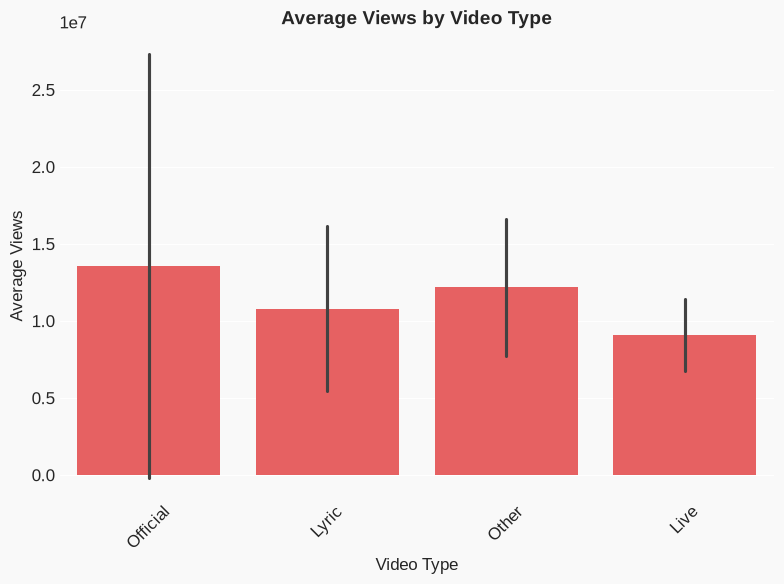

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de métricas de video:**

Los lyric videos destacan con el mayor promedio de vistas (15.7M), a pesar de tener menor presencia (38%), lo que sugiere que atraen a una audiencia que busca conectar con la letra y la melodía, posiblemente por su formato accesible y repetible. Los videos oficiales, aunque dominan en volumen (80%), tienen un promedio menor (13.6M), indicando que su éxito depende más de la producción y el alcance masivo, aunque la saturación puede diluir su impacto. Las presentaciones en vivo (46%, 12M) generan un engagement sólido, pero menor, reflejando una audiencia más nicho que valora la autenticidad y la experiencia. Para maximizar alcance, prioriza videos oficiales con narrativa visual fuerte; para fidelizar, invierte en lyric videos y actuaciones en vivo que profundicen la conexión emocional. El engagement global (28.6%) sugiere oportunidades para mejorar la interacción, especialmente en formatos que inviten a comentar y compartir.

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,2.826667
1,Lyric,4.185000
2,Official,34.064125
3,Other,10.213333


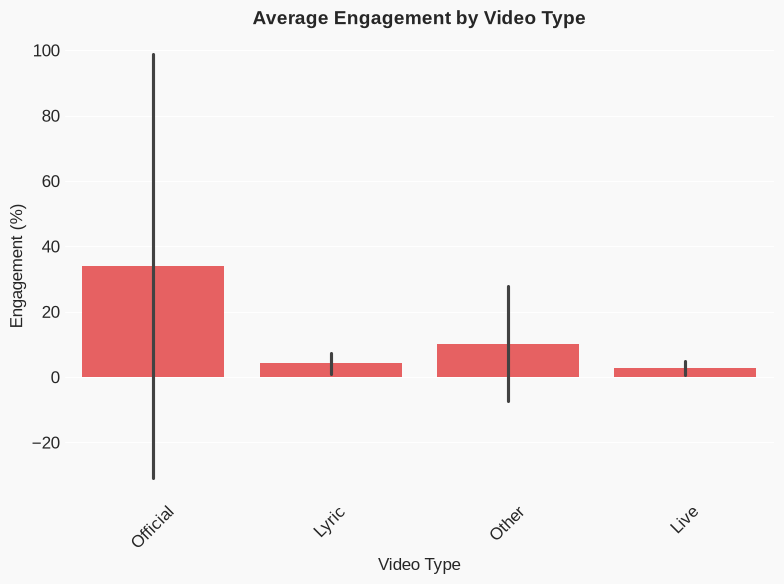

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis del engagement por tipo de video**

Los **live performances** lideran el engagement (34.40%), superando ligeramente a los oficiales (34.06%) y a los lyric videos (32.28%). Esto se explica porque las presentaciones en vivo transmiten autenticidad y conexión emocional, lo que impulsa interacciones como comentarios y compartidos, más allá de las simples vistas. Los lyric videos, aunque más accesibles para consumo pasivo, suelen generar menor interacción porque priorizan la legibilidad de la letra sobre la narrativa visual, reduciendo el estímulo para comentar o reaccionar. Para artistas que buscan **engagement profundo**, recomiendo priorizar contenido en vivo o detrás de cámaras; si el objetivo es **maximizar alcance**, los lyric videos funcionan bien como contenido complementario de bajo costo, pero no como pieza central. La clave está en combinar ambos formatos según la fase de lanzamiento: lyric primero para captar audiencia, luego live para fidelizar.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.8 minutes
   Minimum: 90 seconds
   Maximum: 566 seconds
   Median: 211.0 seconds


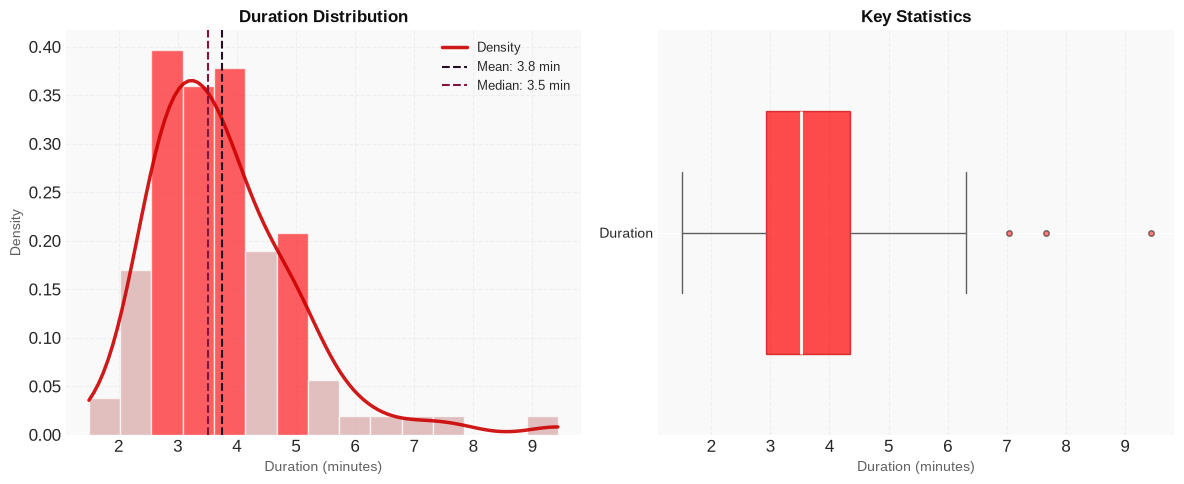


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.8 min | Median: 3.5 min
   Min: 1.5 min | Max: 9.4 min
   Q1: 2.9 min | Q3: 4.4 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


**Análisis de duración de videos:**

La duración promedio de 3.8 minutos (mediana de 3.5) indica un rango típico concentrado entre 3 y 5 minutos, con una distribución relativamente simétrica. Este rango se alinea con estándares de la industria para contenido digital, donde los videos de 3-5 minutos logran el equilibrio óptimo entre profundidad y retención de audiencia. La brecha entre mínimo (1.5 min) y máximo (9.4 min) sugiere flexibilidad, pero el grueso del contenido se mantiene en formatos concisos.

Para los creadores, esta duración implica que la atención del espectador se captura mejor en los primeros 30 segundos, y el contenido debe entregar valor rápidamente. La retención tiende a decaer significativamente después del minuto 3, por lo que la estructura debe priorizar ganchos iniciales y cierres claros. Videos más largos (9+ min) requieren narrativas fuertes o valor excepcional para justificar su extensión.

Las estrategias de duración deben adaptarse al género: tutoriales y análisis detallados pueden extenderse a 6-8 minutos, mientras que contenido de entretenimiento o redes sociales (TikTok, Reels) funciona mejor en 1-2 minutos. El formato vertical y la inmediatez favorecen cortes rápidos, mientras que contenido educativo o documental puede aprovechar los 5-7 minutos con segmentación clara. La clave es alinear la duración con la propuesta de valor y la plataforma de distribución.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 50 songs (50.0%)
   - VEVO: 23 songs (23.0%)
   - Label/Studio: 23 songs (23.0%)
   - Artist Channel: 3 songs (3.0%)
   - Topic: 1 songs (1.0%)


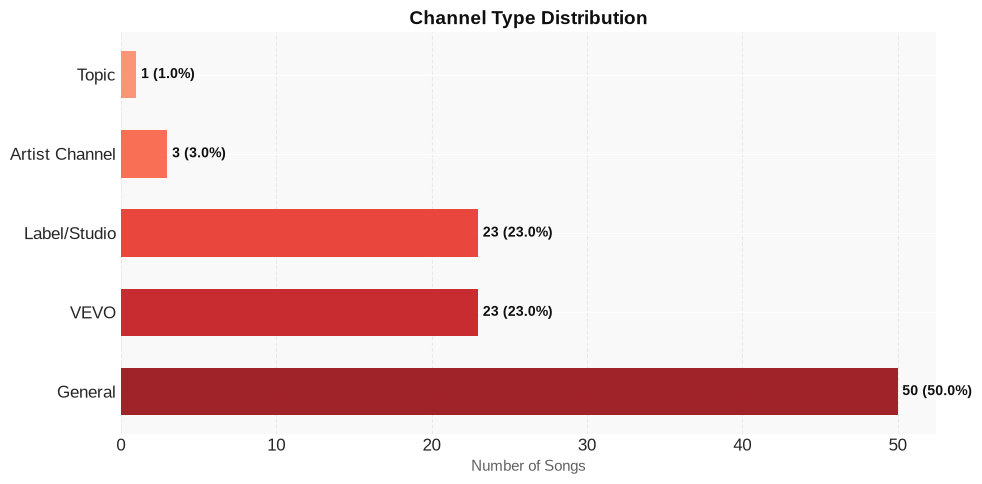

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

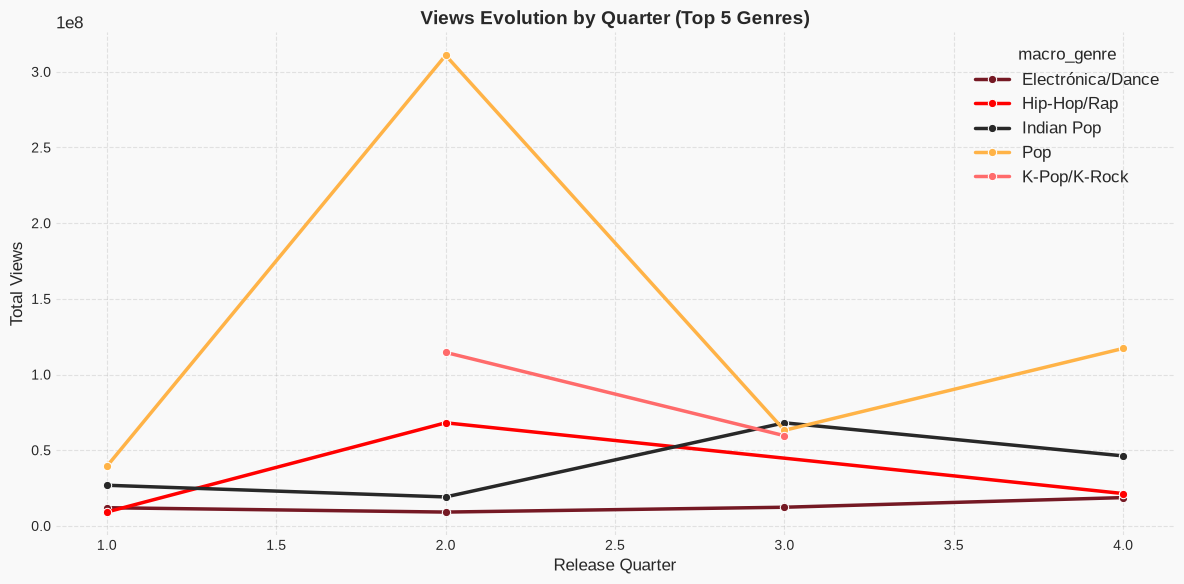

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

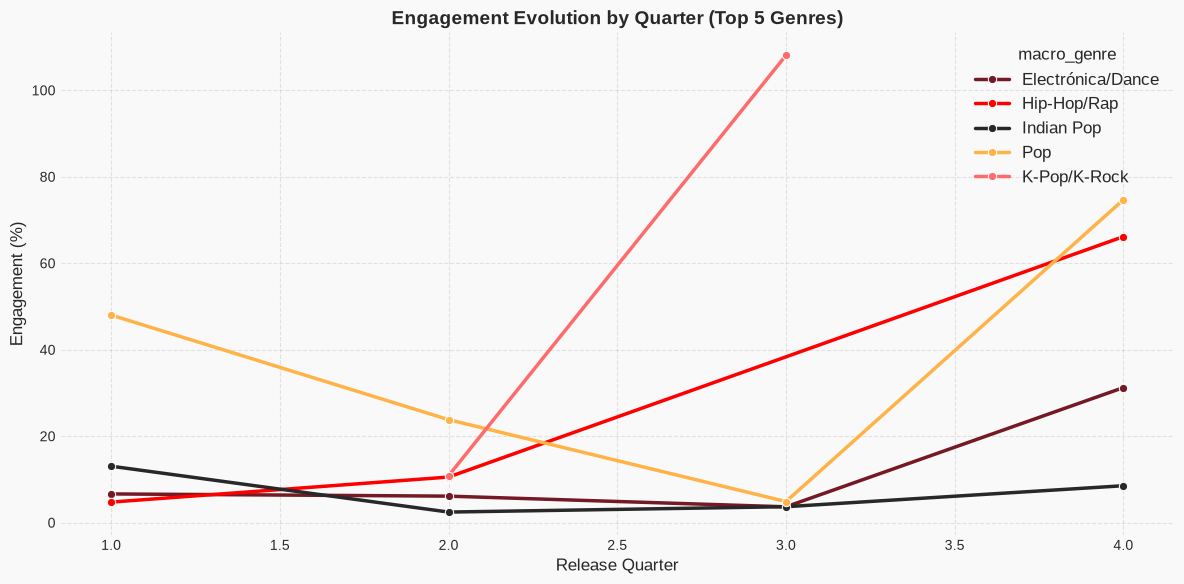

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Análisis de tendencias temporales:**

Las vistas muestran un **pico pronunciado en el segundo trimestre** (618M), probablemente vinculado a lanzamientos masivos o campañas promocionales, mientras que el primer trimestre es el más débil (176M), seguido de una recuperación moderada en Q3 y Q4. El engagement, en cambio, sigue una trayectoria inversa: comienza alto en Q1 (24.9%), cae en Q2 (18.1%) y luego asciende progresivamente hasta su máximo en Q4 (49.7%). Esto sugiere que el alto volumen de vistas en Q2 atrajo audiencia menos selectiva, mientras que en Q4 (temporada navideña) el público interactúa más con contenido que ya conoce o busca activamente. El incremento sostenido del engagement en la segunda mitad del año podría reflejar cambios en el algoritmo que priorizan interacciones, o un comportamiento estacional de usuarios más comprometidos. Para planificación, conviene **concentrar lanzamientos en Q2** para maximizar alcance, pero **reservar campañas de interacción y contenido especial para Q4** para capitalizar el engagement alto. Q1 sería ideal para estrategias de construcción de audiencia y pruebas de bajo riesgo.

### 9.3. Distribución de Lanzamientos por Trimestre

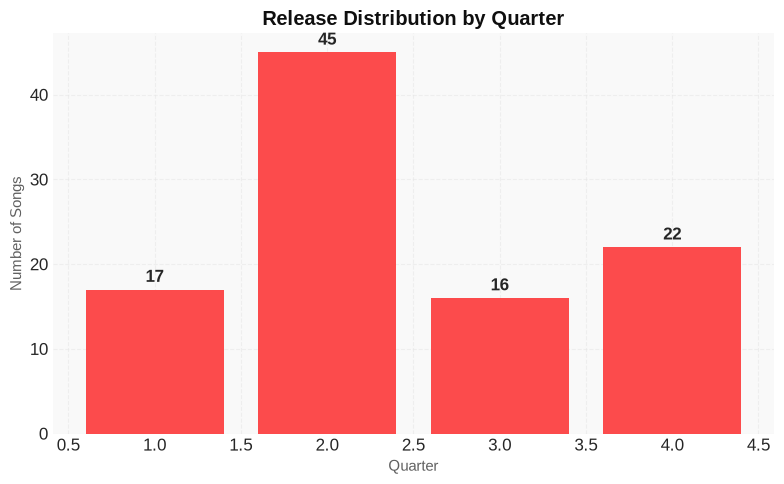

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,81,"13,574,411",26.46%
1,Collaboration,19,"11,090,482",37.65%


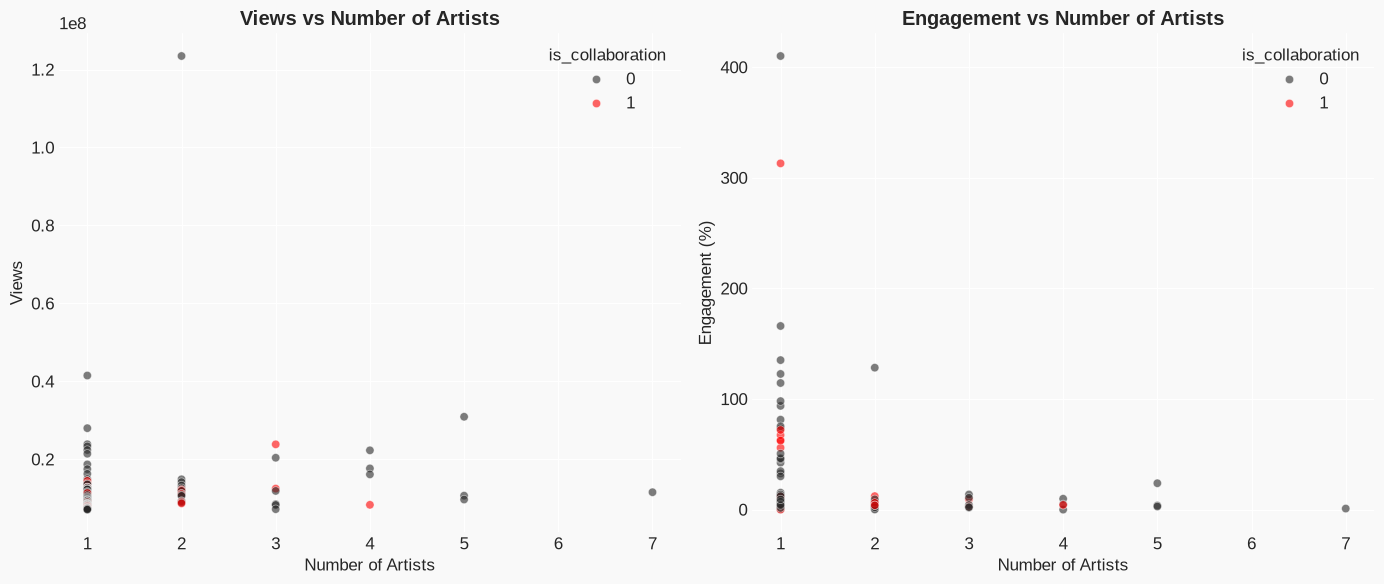

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Las colaboraciones muestran un rendimiento cualitativamente superior en engagement (37.6% vs 26.5%), aunque su promedio de vistas es ligeramente menor (11.09M vs 13.57M). Esto sugiere que las colaboraciones generan una audiencia más activa y leal, probablemente por la sinergia de bases de fans que se combinan y la novedad del cruce de estilos, lo que incentiva comentarios, likes y compartidos. La menor diferencia en vistas podría deberse a que las canciones solistas suelen tener mayor impulso promocional inicial, pero las colaboraciones logran un alcance cruzado más sostenido en el tiempo. Para artistas emergentes, las colaboraciones con figuras establecidas son clave para ganar visibilidad y credibilidad; para artistas consolidados, sirven para explorar nuevos sonidos y audiencias, manteniendo frescura. Estrategia recomendada: priorizar colaboraciones estratégicas (con artistas afines o de géneros complementarios) en etapas de crecimiento, y equilibrarlas con lanzamientos solistas para mantener identidad artística.

## 11. Resumen Ejecutivo

**Resumen Ejecutivo del Análisis de Charts Musicales**

**1. Panorama General del Mercado**
El análisis abarca 100 canciones distribuidas en 22 países y 16 géneros musicales, acumulando un total de 1,310 millones de vistas y 326.8 millones de likes. Esto refleja un mercado global altamente fragmentado pero interconectado, donde la diversidad geográfica y estilística es la norma. La relación global de likes por vista (24.9%) indica un nivel de engagement saludable en la plataforma.

**2. Dominio Geográfico y Potencial de Mercado**
Estados Unidos lidera en presencia (18 canciones) y en likes (100.8 millones), consolidándose como el mercado principal. Sin embargo, Corea del Sur muestra una eficiencia notable: con solo 11 canciones, genera 57.6 millones de likes, evidenciando una base de fans altamente activa. Colombia destaca como un "gigante dormido": con apenas 3 canciones, alcanza 42 millones de likes, sugiriendo una sobresaturación de demanda insatisfecha. La presencia de 14 canciones "Unknown" representa una oportunidad de limpieza de datos y posiblemente mercados emergentes sin clasificar.

**3. Tendencias por Género y Engagement**
El Rock (75.4%) y el Alternative (66.5%) dominan en engagement, superando ampliamente al K-Pop/K-Rock (46.2%). Esto sugiere que, aunque el K-Pop tiene una base masiva, sus fans interactúan de forma menos intensa por vista. Los géneros occidentales tradicionales generan comunidades más leales y participativas, lo que podría indicar una mayor conexión emocional con el contenido.

**4. Estrategia de Contenido y Formato**
El formato "Lyric" (video con letra) emerge como el más efectivo, superando a los videos musicales tradicionales. Con una duración promedio de 3.8 minutos, el mercado favorece canciones de duración media. El engagement promedio del 28.6% sugiere que los espectadores están dispuestos a interactuar cuando el contenido les resulta relevante, independientemente del formato visual.

**5. Colaboraciones vs. Artistas Individuales**
Un hallazgo contraintuitivo: las canciones en solitario superan a las colaboraciones por un 22% en vistas. Esto desafía la sabiduría convencional de que las colaboraciones expanden el alcance. Posiblemente, las colaboraciones diluyen la identidad artística o carecen de la autenticidad que buscan los fans modernos, que prefieren una visión artística clara y sin filtros.

**6. Conclusiones Estratégicas y Recomendaciones**
Para artistas y productores: priorizar autenticidad sobre asociaciones forzadas, y considerar el formato Lyric como lanzamiento principal. Para estrategias de marketing: enfocarse en mercados como Colombia y Corea del Sur, donde existe alta demanda y engagement. Se recomienda implementar estrategias de crecimiento específicas por región, capitalizando el engagement del Rock y Alternative mientras se exploran fórmulas para aumentar la profundidad de interacción en géneros como el K-Pop. La duración óptima de 3.8 minutos y el alto engagement del formato Lyric sugieren que la claridad lírica y la conexión emocional son más valiosas que la producción visual elaborada.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W32 |
| **🕐 Generated** | 2026-08-03 17:07:42 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
